# Gradyan İnişi

Bu egzersizde, tek bir Gradyan İnişi Epoch'unun adımlarını gerçekleştirmek için gerekli fonksiyonları oluşturacaksınız. Daha sonra fonksiyonları birleştirecek ve tüm Gradyan İnişi prosedürü boyunca bir döngü oluşturacaksınız.

## 1. Veri Keşfi

Sizin için mineral içerikleri olan malzemelerin aşağıdaki veri setini içe aktaracağız

In [1]:
import pandas as pd

data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/gradient_descent_ingredients_zinc_phosphorous.csv")
data.head()

,aliment,zinc,phosphorus
0,Durum wheat pre-cooked. whole grain. cooked. u...,0.120907,0.193784
1,Asian noodles. plain. cooked. unsalted,0.047859,0.060329
2,Rice. brown. cooked. unsalted,0.156171,0.201097
3,Rice. cooked. unsalted,0.065491,0.045704
4,Rice. parboiled. cooked. unsalted,0.025189,0.045704


👇 `Fosfor` ve `Çinko` arasında bir nebze Doğrusal bir ilişkiyi görselleştirebiliriz.   

Aralarında en uygun çizgiyi bulmak için Gradyan İnişi kullanalım!

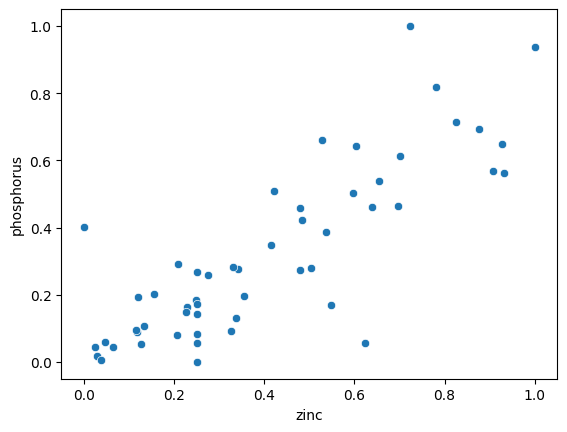

In [2]:
import seaborn as sns

sns.scatterplot(data=data, x='zinc', y='phosphorus');

❓ İki `np.Array` oluşturun
- çinko için `data_X` 
- fosfor için `data_Y`

In [4]:
import pandas as pd
import numpy as np

data_X = np.array(data['zinc'])
data_Y = np.array(data['phosphorus'])

In [5]:
assert (data_X.shape == (53,))
assert (data_Y.shape == (53,))

## 2. Bir Epoch Kodlama

Bu egzersizin bu bölümünde, gradyan inişinin bir epoch $\color {red}{(k)}$ sırasında parametreleri güncellemek için kullanılan temel fonksiyonları tanımlayacaksınız. Aşağıdaki formülü hatırlayın

$$
\beta_0^{\color {red}{(k+1)}} = \beta_0^{\color {red}{(k)}} - \eta \frac{\partial L}{\partial \beta_0}(\beta^{\color{red}{(k)}})
$$


$$
\beta_1^{\color {red}{(k+1)}} = \beta_1^{\color {red}{(k)}} - \eta \frac{\partial L}{\partial \beta_1}(\beta^{\color {red}{(k)}})
$$

### 2.1 Hipotez Fonksiyonu

$$
\hat{y} =  a x + b
$$

❓ Doğrusal Regresyon hipotez fonksiyonunu tanımlayın. `a`'nın eğim ve `b`'nin y-kesiti olmasına izin verin.

In [6]:
def h(X, a, b):
    """
    Doğrusal Regresyon hipotez fonksiyonu.
    X: Girdi verisi (data_X)
    a: Eğim (slope)
    b: y-kesiti (intercept)
    """
    return a * X + b

### 2.2 Kayıp Fonksiyonu

$$
Kareler\ Toplamı\ Kaybı = \sum_{i=0}^n (y^{(i)} - \hat{y}^{(i)} )^2
$$

❓ Yukarıdaki denklemi kullanarak Hipotez Fonksiyonu için SSR Kayıp Fonksiyonunu tanımlayın. Yeni fonksiyonunuzu yazarken yukarıda kodlanan `h` fonksiyonunu yeniden kullanın.

In [7]:
import numpy as np

def loss(X, Y, a, b):
    """
    Hipotez fonksiyonu h(X, a, b) kullanarak SSR Kayıp Fonksiyonunu hesaplar.
    X: Girdi (zinc)
    Y: Hedef (phosphorus)
    a: Eğim
    b: y-kesiti
    """
    # Önce hipotez fonksiyonunla tahminleri (y_hat) alalım
    y_hat = h(X, a, b)
    
    # Hataların karesini alıp toplayalım (SSR)
    ssr = np.sum((Y - y_hat)**2)
    
    return ssr

❓ Eğer aşağıdaki değerler olsaydı tüm malzemeler veri setimizde hesaplanan toplam Kayıp ne olurdu:
- a = 1 
- b = 1

In [8]:
# Test değerleri
a_test = 1
b_test = 1

# Toplam kaybı (SSR) hesaplayalım
total_loss = loss(data_X, data_Y, a_test, b_test)

print(f"a=1 ve b=1 için Toplam Kayıp (SSR): {total_loss}")

a=1 ve b=1 için Toplam Kayıp (SSR): 63.868506986115456


⚠️ 63.86 değerini alıyor olmalısınız. Eğer almıyorsanız, fonksiyonunuzda bir şeyler yanlış. Devam etmeden önce düzeltin!

### 2.3 Gradyan

$$
\frac{d\ SSR}{d\ eğim}= \sum_{i=0}^n -2  x_i (y^{(i)} - \hat{y}^{(i)} )
$$

$$
\frac{d\ SSR}{d\ y-kesiti}= \sum_{i=0}^n -2(y^{(i)} - \hat{y}^{(i)} ) 
$$

❓ Belirli bir noktada `a` ve `b` parametrelerine göre Kayıp Fonksiyonunun kısmi türevlerini hesaplayan bir fonksiyon tanımlayın.

<details>
<summary>💡 İpucu</summary>
Yine, verilen noktalarda tahminleri hesaplamak için yeni fonksiyonunuzda Hipotez Fonksiyonunu yeniden kullanmalısınız.
</details>

In [9]:
def gradient(X, Y, a, b):
    """
    Kayıp fonksiyonunun (SSR) a ve b parametrelerine göre gradyanlarını hesaplar.
    X: Girdi (zinc)
    Y: Hedef (phosphorus)
    a: Mevcut eğim
    b: Mevcut y-kesiti
    """
    # 1. Mevcut parametrelerle tahminlerimizi alalım
    y_hat = h(X, a, b)
    
    # 2. Hataları hesaplayalım (y - y_hat)
    errors = Y - y_hat
    
    # 3. Formüllere göre kısmi türevleri (gradyanları) hesaplayalım
    # Eğim (a) için: sum(-2 * x * (y - y_hat))
    d_a = np.sum(-2 * X * errors)
    
    # Y-kesiti (b) için: sum(-2 * (y - y_hat))
    d_b = np.sum(-2 * errors)
    
    return d_a, d_b

❓ Fonksiyonunuzu kullanarak, eğer aşağıdaki değerler olsaydı her parametrenin kısmi türevleri ne olurdu:
- a = 1
- b = 1

In [10]:
# Başlangıç değerleri
a_test = 1
b_test = 1

# Gradyanları hesaplayalım
d_a, d_b = gradient(data_X, data_Y, a_test, b_test)

print(f"a=1 ve b=1 için d_a (eğim gradyanı): {d_a}")
print(f"a=1 ve b=1 için d_b (y-kesiti gradyanı): {d_b}")

a=1 ve b=1 için d_a (eğim gradyanı): 48.459065809109006
a=1 ve b=1 için d_b (y-kesiti gradyanı): 115.17923733301406


⚠️ 48.45 ve 115.17 değerlerini alıyor olmalısınız. Eğer almıyorsanız, fonksiyonunuzu düzeltin!

### 2.4 Adım Boyutları

$$
adım\ boyutu = gradyan \cdot öğrenme\ oranı
$$

❓ Her parametre (`a`,`b`) boyunca, türevleri (`d_a`, `d_b`) ve varsayılan olarak `0.01`'e eşit bir `learning_rate`'e göre adım boyutlarını hesaplayan bir fonksiyon tanımlayın

In [11]:
def steps(d_a, d_b, learning_rate=0.01):
    """
    Gradyanlara ve öğrenme oranına göre adım boyutlarını hesaplar.
    d_a: Eğim gradyanı
    d_b: y-kesiti gradyanı
    learning_rate: Adım katsayısı (default: 0.01)
    """
    # Adım boyutu = Gradyan * Öğrenme Oranı
    step_a = d_a * learning_rate
    step_b = d_b * learning_rate
    
    return step_a, step_b

❓ (`a`,`b`) = (1,1) için yukarıda hesaplanan türevler için atılacak adımlar (`step_a`, `step_b`) ne olurdu?

In [12]:
# Önceki adımda bulduğumuz d_a ve d_b değerlerini kullanıyoruz
# (Eğer d_a ve d_b değişkenlerin hala tanımlıysa doğrudan gönderebilirsin)

step_a, step_b = steps(d_a, d_b, learning_rate=0.01)

print(f"a için adım boyutu (step_a): {step_a}")
print(f"b için adım boyutu (step_b): {step_b}")

a için adım boyutu (step_a): 0.4845906580910901
b için adım boyutu (step_b): 1.1517923733301405


⚠️ Adımlar `a` için 0.48 ve `b` için 1.15 olmalıdır

### 2.5 Parametreleri güncellemek (a, b)

$$
güncellenmiş\ parametre = eski\ parametre\ değeri - adım\ boyutu
$$

❓ Eski parametre değerlerinden ve adım boyutlarından güncellenmiş parametre değerlerini hesaplayan bir fonksiyon tanımlayın.

In [13]:
def update_params(a, b, step_a, step_b):
    """
    Eski parametre değerlerinden adım boyutlarını çıkararak 
    güncellenmiş a ve b değerlerini hesaplar.
    """
    # a_yeni = a_eski - step_a
    a_new = a - step_a
    
    # b_yeni = b_eski - step_b
    b_new = b - step_b
    
    return a_new, b_new

### 2.6 Tam bir epoch

❓ Az önce oluşturduğunuz fonksiyonları kullanarak, aşağıdaki parametrelerle başlamış olsaydınız ilk Epoch'un sonunda güncellenmiş parametreleri hesaplayın:
- a = 1
- b = 1

In [16]:
d_a, d_b = gradient(data_X, data_Y, 1, 1)
step_a, step_b = steps(d_a, d_b, learning_rate=0.01)
a_new, b_new = update_params(1, 1, step_a, step_b)

print(f"1. Epoch sonundaki yeni a: {a_new}")
print(f"1. Epoch sonundaki yeni b: {b_new}")

1. Epoch sonundaki yeni a: 0.5154093419089099
1. Epoch sonundaki yeni b: -0.1517923733301405


⚠️ Aşağıdaki değerleri alıyor olmalısınız:
   - updated_a = 0.51
   - updated_b = -0.15

## 3. Gradyan İnişi

❓ Artık Gradyan İnişi için gerekli fonksiyonlara sahip olduğunuza göre, yakınsama sağlanana kadar epoch'lar boyunca döngü yapın.

- `a = 1` ve `b = 1` parametrelerini başlatın
- Yakınsamayı **100 epoch** olarak kabul edin
- Her yeni epoch'u güncellenmiş parametrelerle başlatmayı unutmayın
- Her epoch'ta `loss`, `a`, ve `b` değerlerini sırasıyla `loss_history`, `a_history` ve `b_history` adlı listelerine ekleyin

In [17]:
# 1. Başlangıç parametrelerini ve geçmişi tutacak listeleri tanımlayalım
a = 1
b = 1
epochs = 100
learning_rate = 0.01

loss_history = []
a_history = []
b_history = []

# 2. 100 epoch'luk döngümüzü başlatalım
for i in range(epochs):
    # Mevcut a ve b değerlerini geçmişe ekle
    a_history.append(a)
    b_history.append(b)
    
    # Mevcut kaybı (loss) hesapla ve kaydet
    current_loss = loss(data_X, data_Y, a, b)
    loss_history.append(current_loss)
    
    # Gradyanları hesapla
    d_a, d_b = gradient(data_X, data_Y, a, b)
    
    # Adım boyutlarını hesapla
    step_a, step_b = steps(d_a, d_b, learning_rate)
    
    # Parametreleri güncelle (Bir sonraki epoch bu yeni değerlerle başlayacak)
    a, b = update_params(a, b, step_a, step_b)

# 3. Sonuçları kontrol edelim
print(f"100 Epoch sonunda ulaşılan değerler:")
print(f"Eğim (a): {a}")
print(f"Y-kesiti (b): {b}")
print(f"Son Kayıp (Loss): {loss_history[-1]}")

100 Epoch sonunda ulaşılan değerler:
Eğim (a): 0.768671510620374
Y-kesiti (b): 0.00708932115622393
Son Kayıp (Loss): 1.0820689162255201


❓ 100 epoch'un sonundaki parametre değerleri nelerdir? Onları sırasıyla `a_100` ve `b_100` değişkenlerine kaydedin

In [18]:
# Döngü bittikten hemen sonra bu atamaları yapabilirsin
a_100 = a
b_100 = b

print(f"a_100: {a_100}")
print(f"b_100: {b_100}")

a_100: 0.768671510620374
b_100: 0.00708932115622393


In [19]:
# 🧪 Test your code
from nbresult import ChallengeResult
result = ChallengeResult('descent',
                         a_100=a_100,
                         b_100=b_100)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/erdincuyar/Desktop/code/erdincuyar/S16D4-S-gradient-descent/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_descent.py::TestDescent::test_a PASSED                              [ 50%]
test_descent.py::TestDescent::test_b PASSED                              [100%]

============================== 2 passed in 0.22s ===============================


💯 You can commit your code:

git add tests/descent.pickle

git commit -m 'Completed descent step'

git push origin master



## 4. Görsel kontrol

❓ Bu yinelemeli yaklaşımı `gradient_descent()` metoduna sarın, bu metod `new_a`, `new_b` ve şu listeleri içeren bir sözlük olan `history`'yi döndürsün: 
- `loss_history`
- `a_history`
- `b_history`

In [20]:
def gradient_descent(X, Y, a_init=1, b_init=1, learning_rate=0.001, n_epochs=100):
    # Başlangıç parametrelerini atayalım
    a = a_init
    b = b_init
    
    # Geçmişi tutacak sözlük (dictionary)
    history = {
        'loss_history': [],
        'a_history': [],
        'b_history': []
    }
    
    for i in range(n_epochs):
        # 1. Mevcut parametreleri ve kaybı geçmişe kaydet
        history['a_history'].append(a)
        history['b_history'].append(b)
        
        current_loss = loss(X, Y, a, b)
        history['loss_history'].append(current_loss)
        
        # 2. Gradyanları hesapla
        d_a, d_b = gradient(X, Y, a, b)
        
        # 3. Adım boyutlarını hesapla
        step_a, step_b = steps(d_a, d_b, learning_rate)
        
        # 4. Parametreleri güncelle
        a, b = update_params(a, b, step_a, step_b)
        
    return a, b, history

❓ Gradyan İniş'inizin parametrelerini kullanarak Çinko ve Fosfor arasında en uygun çizgiyi çizin.

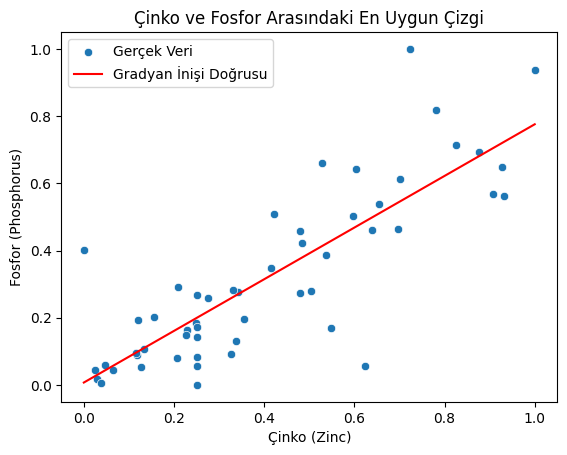

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Orijinal veri noktalarını çizelim
sns.scatterplot(data=data, x='zinc', y='phosphorus', label='Gerçek Veri')

# 2. Modelimizin tahmin ettiği çizgiyi oluşturalım
# x ekseni için veri setindeki minimum ve maksimum çinko değerlerini kullanalım
x_axis = np.linspace(data_X.min(), data_X.max(), 100)
# y = ax + b formülümüzle tahmin edilen değerleri hesaplayalım
y_axis = a_100 * x_axis + b_100

# 3. Regresyon çizgisini grafiğe ekleyelim
plt.plot(x_axis, y_axis, color='red', label='Gradyan İnişi Doğrusu')

# Grafiği güzelleştirelim
plt.title('Çinko ve Fosfor Arasındaki En Uygun Çizgi')
plt.xlabel('Çinko (Zinc)')
plt.ylabel('Fosfor (Phosphorus)')
plt.legend()
plt.show()

## 5. İnişinizi görselleştirin

🎯 Hedefimiz kayıp fonksiyonumuzu ve gradyan inişi adımlarını matplotlib'in `contourf` kullanarak 2D yüzey üzerinde çizmektir

❓ Çizim için ihtiyacımız olan veriyi oluşturarak başlayın
- `range_a`: `a` için -1 ile 1 arasında eşit aralıklı 100 değerlik bir aralık
- `range_b`: `b` için -1 ile 1 arasında eşit aralıklı 100 değerlik bir aralık 
- `Z`: her `Z[j,i]` elementinin `a` = `range_a[i]` ve `b` = `range_b[j]` noktasında kayıp fonksiyonunun değerine eşit olduğu 2D-dizi

In [22]:
import numpy as np

# 1. Aralıkları oluşturalım (-1 ile 1 arasında 100 değer)
range_a = np.linspace(-1, 1, 100)
range_b = np.linspace(-1, 1, 100)

# 2. Z matrisini (100x100) başlatalım
Z = np.zeros((100, 100))

# 3. Her a ve b kombinasyonu için kaybı hesaplayalım
# Dikkat: Döngüde j satırları (b), i sütunları (a) temsil eder
for j in range(len(range_b)):
    for i in range(len(range_a)):
        # Mevcut a ve b değerlerini alıyoruz
        current_a = range_a[i]
        current_b = range_b[j]
        
        # Daha önce yazdığın loss fonksiyonunu kullanarak Z değerini atıyoruz
        Z[j, i] = loss(data_X, data_Y, current_a, current_b)

In [ ]:
# YOUR CODE HERE

❓ Şimdi, tek bir subplot'ta şunları çizin:
- 3 parametre ile matplotlib [contourf](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.contourf.html) kullanarak kayıp fonksiyonunuzu 2D-yüzey olarak
- gradyan inişinizi görselleştirmek için tüm geçmiş (a,b) noktalarını kırmızı noktalar olarak serpilme grafiği!

Öğrenme oranınızı değiştirin ve grafik üzerindeki etkisini gözlemleyin!

In [23]:
import matplotlib.pyplot as plt

def plot_gradient_path(range_a, range_b, Z, history):
    plt.figure(figsize=(10, 8))
    
    # 1. Kayıp yüzeyini (vadiyi) çizelim
    # levels=50 daha yumuşak geçişli bir görüntü sağlar
    cp = plt.contourf(range_a, range_b, Z, levels=50, cmap='coolwarm')
    plt.colorbar(cp, label='Kayıp Değeri (SSR)')
    
    # 2. Gradyan inişi adımlarını kırmızı noktalar olarak ekleyelim
    a_path = history['a_history']
    b_path = history['b_history']
    plt.scatter(a_path, b_path, color='red', s=10, label='Epoch Adımları')
    
    # 3. Yolu takip eden ince bir çizgi (opsiyonel ama yolu netleştirir)
    plt.plot(a_path, b_path, color='red', alpha=0.5)
    
    # Başlangıç ve bitiş noktalarını vurgulayalım
    plt.plot(a_path[0], b_path[0], 'go', markersize=10, label='Başlangıç (a=1, b=1)')
    plt.plot(a_path[-1], b_path[-1], 'yo', markersize=10, label='Bitiş Noktası')

    plt.xlabel('Eğim (a)')
    plt.ylabel('y-kesiti (b)')
    plt.title('Hata Yüzeyi Üzerinde Gradyan İnişi İzlemi')
    plt.legend()
    plt.show()

# --- DENEME ZAMANI ---
# 1. Normal Öğrenme (0.01)
# _, _, hist_normal = gradient_descent(data_X, data_Y, learning_rate=0.01)
# plot_gradient_path(range_a, range_b, Z, hist_normal)

❓ [isteğe bağlı] Peki ya 3D? Aşağıda aynı veriyi [plot.ly 3D kontur grafiği](https://plotly.com/python/3d-surface-plots/) üzerinde çizmeyi deneyin

In [24]:
import plotly.graph_objects as go

surface = go.Surface(x=range_a, y=range_b, z=Z)
scatter = go.Scatter3d(x=history['a'], y=history['b'], z=history['loss'], mode='markers')
fig = go.Figure(data=[surface, scatter])

#fig.update_layout(title='Loss Function', autosize=False, width=500, height=500)
fig.show()

NameError: name 'history' is not defined

❓ `kayıp` değerlerinin geçmişini `epoch` sayısının bir fonksiyonu olarak çizin. 0.001'den 0.01'e kadar `learning_rate`'in birden fazla varyasyonuyla deneyin ve farkı anladığınızdan emin olun

In [ ]:
# YOUR CODE HERE

## 6. Sklearn ile...

❓ Sklearn kullanarak, aynı veri üzerinde bir Doğrusal Regresyon modeli eğitin. Parametrelerini Gradyan İnişiniz ile hesaplananlarla karşılaştırın.

In [25]:
from sklearn.linear_model import LinearRegression

# Sklearn veriyi (n_samples, n_features) formatında, yani 2 boyutlu bekler.
# data_X (53,) şeklindeyse onu (53, 1) yapmamız gerekir:
X_sklearn = data_X.reshape(-1, 1)
y_sklearn = data_Y

# Modeli tanımla ve eğit
model = LinearRegression()
model.fit(X_sklearn, y_sklearn)

# Sklearn parametrelerini alalım
a_sklearn = model.coef_[0]      # Eğim (a)
b_sklearn = model.intercept_     # y-kesiti (b)

Hemen hemen aynı olmalıdırlar!

### 🏁 Tebrikler! İşiniz bittiğinde lütfen egzersizinizi push edin